# 毫米波雷达

## 参考资料
- [FMCW Radar Part 1 – Ranging](https://wirelesspi.com/fmcw-radar-part-1-ranging/)
- [FMCW Radar Part 2 – Velocity, Angle and Radar Data Cube](https://wirelesspi.com/fmcw-radar-part-2-velocity-angle-and-radar-data-cube/)
- [FMCW Radar Part 3 – Design Guidelines](https://wirelesspi.com/fmcw-radar-part-3-design-guidelines/)


## 雷达波形

In [11]:
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from scipy import signal
from scipy.constants import c, pi, mph
from numpy.fft import fft, fftshift, fft2
from matplotlib import cm

%matplotlib inline
plt.style.use("ggplot")

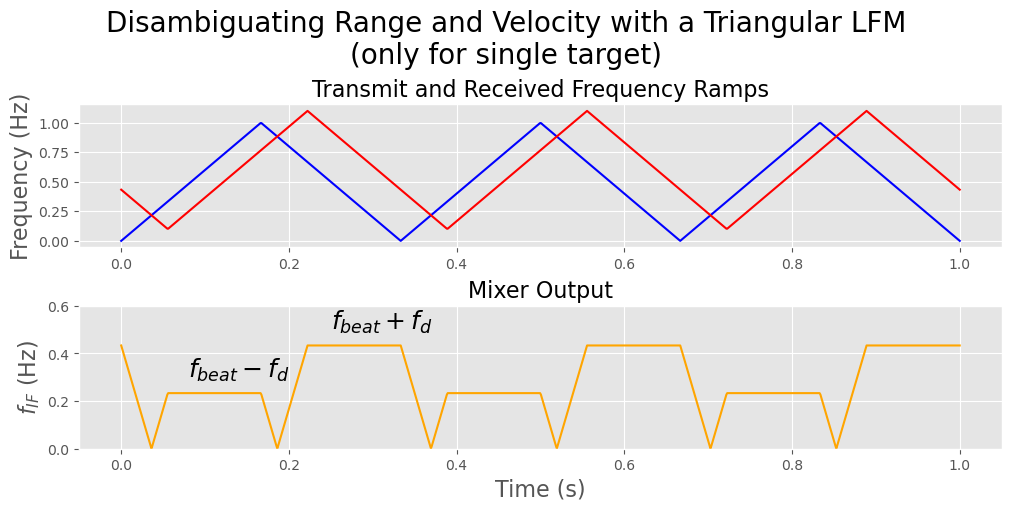

In [12]:
t = np.linspace(0, 1, 1000)
f = 3
range_shift = -pi / 3
doppler_shift = 0.1
tx = (signal.sawtooth(2 * pi * f * t, width=0.5) + 1) / 2
rx = (signal.sawtooth(2 * pi * f * t + range_shift, width=0.5) + 1) / 2 + doppler_shift
if_sig = np.abs(tx - rx)


fig, ax = plt.subplots(2, 1, figsize=(10, 5), layout="constrained")
fig.suptitle(
    "Disambiguating Range and Velocity with a Triangular LFM\n(only for single target)",
    fontsize=20,
)
ax[0].set_ylabel("Frequency (Hz)", fontsize=16)
ax[0].set_title("Transmit and Received Frequency Ramps", fontsize=16)
ax[0].plot(t, tx, label="Tx", c="b")
ax[0].plot(t, rx, label="Rx", c="r")
ax[1].set_ylim([0, 0.6])
ax[1].set_ylabel(r"$f_{IF}$ (Hz)", fontsize=16)
ax[1].set_xlabel("Time (s)", fontsize=16)
ax[1].set_title("Mixer Output", fontsize=16)
ax[1].text(0.08, 0.3, r"$f_{beat} - f_d$", fontsize=18)
ax[1].text(0.25, 0.5, r"$f_{beat} + f_d$", fontsize=18)
ax[1].plot(t, if_sig, label="Rx", c="orange")
plt.show()

这意味着我们现在有两个已知量：

\begin{equation}
f_{\rm up} = f_{\rm beat} - f_d,\qquad
f_{\rm down} = f_{\rm beat} + f_d
\end{equation}

利用这两个式子，可以解出目标的多普勒频移 $f_d$ 和距离拍频 $f_{\rm beat}$：

\begin{equation}
f_d = \frac{f_{\rm down} - f_{\rm up}}{2},\qquad
f_{\rm beat} = \frac{f_{\rm down} + f_{\rm up}}{2}
\end{equation}

进一步由这两个频率得到目标的距离 $R$ 和径向速度 $v$：

\begin{equation}
R = \frac{c\,T_c\,f_{\rm beat}}{2\,B},\qquad
\end{equation}

\begin{equation}
v = \frac{f_d\,\lambda}{2}
\end{equation}


其中：

- $c$ 是光速  
- $T_c$ 是一次调频（chirp）的时长  
- $B$ 是调频带宽  
- $\lambda = \dfrac{c}{f}$ 是工作波长  

## 差频信号

In [13]:
# Radar setup
f = 76e9  # Hz
Tc = 40e-6  # chirp time - s
bw = 1.6e9  # bandwidth - Hz
chirp_rate = bw / Tc  # Hz/s

wavelength = c / f
M = 40  # number of chirps in coherent processing interval (CPI)

# Target
R = 20  # m
v = 10  # m/s

range_resolution = c / (2 * bw)
print(f"Range resolution: {range_resolution:.2f} m")

time_from_dist = R / c
time_from_vel = 2 * (v * Tc) / c
time_elapsed = time_from_vel + time_from_dist
print(f"Propagation time: {time_elapsed * 1e9:.2f} ns")

Range resolution: 0.09 m
Propagation time: 66.72 ns


完整的相位表达式为

\begin{equation}
\phi_1 = -(2\pi\mu\Delta\tau)\,t
         + \pi\mu\Delta\tau^2
         + 2\pi\mu\tau_0\Delta\tau
         - 2\pi f\,\Delta\tau
         + \phi_0
\end{equation}

其中：

- $\Delta\tau$：相邻两次 chirp 之间因径向速度引起的时间差（`time_from_vel`）  
- $\mu = \dfrac{B}{T_c}$：调频斜率（`chirp_rate`）  
- $\tau_0$：因距离产生的往返时延（`time_from_dist`）  
- $f$：系统载波频率  
- $\phi_0$：初始相位  

在上述五项中，有四分之三的分量幅值非常小，可在实际计算中忽略。  

下面给出一个典型车载雷达系统中，各分量的数值示例：

| 分量           | 表达式                        | 数值示例       |
|----------------|-------------------------------|----------------|
| 线性项         | $2\pi\,\mu\,\Delta\tau\;t$    | $1.2\times10^{-3}$  |
| 二次项         | $\pi\,\mu\,\Delta\tau^2$      | $5.0\times10^{-6}$  |
| 交叉项         | $2\pi\,\mu\,\tau_0\,\Delta\tau$ | $2.3\times10^{-4}$  |
| 载波项         | $2\pi\,f\,\Delta\tau$         | $4.7\times10^{-2}$  |
| 常数项         | $\phi_0$                      | $0.0$           |


$2 \pi f \Delta \tau$ 是最大的相位分量，相比其他分量大几个数量级，因此相位差可近似为：

\begin{equation}
\Delta \phi = \phi_1 - \phi_0 \approx -2 \pi f \Delta \tau
\end{equation}

## 目标距离和速度
记住：

\begin{equation}
R = \frac{c\,T_c\,f_{\rm beat}}{2\,B} \\[6pt]
f_{\rm beat} = \frac{2\,R\,B}{c\,T_c}
\end{equation}

其中：

- $T_c$：一次调频（chirp）的时长（`Tc`）  
- $B$：调频带宽（`bw`）  
- $c$：光速（`c`）  
- $f_{\rm beat}$：由距离产生的拍频（`f_beat`）

In [14]:
def compute_phase_diff(v):
    # 计算因目标径向速度 v 引起的相位差
    # 时间延迟 Δτ = 2·v·Tc / c
    time_from_vel = 2 * (v * Tc) / c  
    # 相位差 Δφ = 2π·f·Δτ
    return 2 * pi * f * time_from_vel  

def compute_f_beat(R):
    # 计算距离 R 对应的拍频
    # f_beat = 2·R·B / (c·Tc)
    return (2 * R * bw) / (c * Tc)  

# 计算并打印拍频和相位差
f_beat = compute_f_beat(R)         # 拍频，单位 Hz
phase_diff = compute_phase_diff(v) # 速度引起的相位差，单位 rad

print(f"Beat frequency: {f_beat/1e6:.2f} MHz")  
print(f"Phase delta: {phase_diff:.2f} radians")  

# 计算多普勒速度测量能力
# 无歧义最大速度 v_max = λ / (4·Tc)
max_vel = wavelength / (4 * Tc)  
# 速度分辨率 Δv = λ / (2·M·Tc)
vel_res = wavelength / (2 * M * Tc)  

print(f"Maximum velocity: {max_vel:.2f} m/s")      
print(f"Velocity resolution: {vel_res:.2f} m/s")   

Beat frequency: 5.34 MHz
Phase delta: 1.27 radians
Maximum velocity: 24.65 m/s
Velocity resolution: 1.23 m/s


下面是单个chirp的回波信号可视化

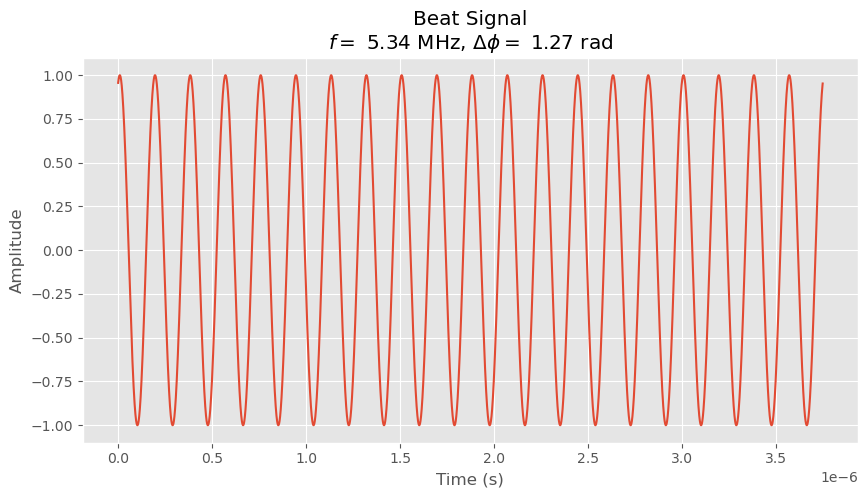

In [15]:
max_time = 20 / f_beat # s
N = 10000
Ts = max_time / N # s
fs = 1 / Ts # Hz

t = np.arange(0, max_time, 1 / fs)

beat_signal = np.sin(2 * pi * compute_f_beat(R) * t + phase_diff)

plt.figure(figsize=(10, 5))
plt.plot(t, beat_signal)
plt.title(
    f"Beat Signal\n"
    f"$f=\\ ${f_beat/1e6:.2f} MHz, $\\Delta \\phi =\\ ${phase_diff:.2f} rad"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

下面是M=64个chirp叠加在一起的回波信号（加窗后），可以看出chirp之间存在相位差，后续基于该相位差可以解算出目标速度信息

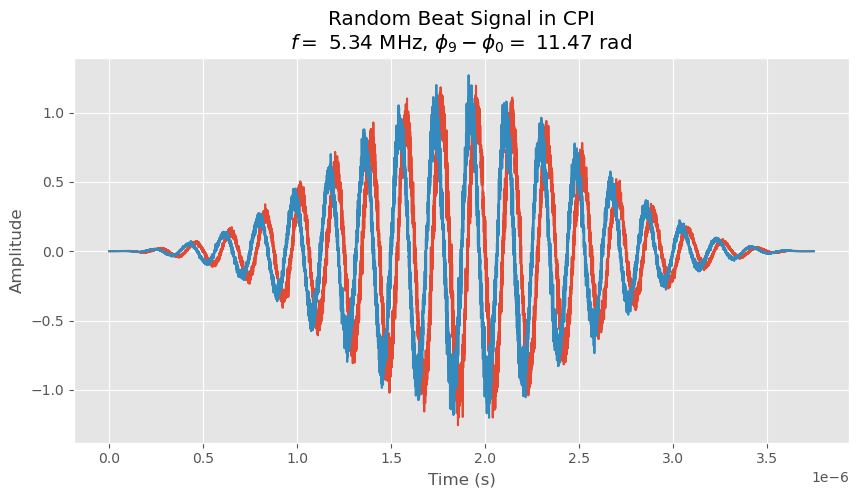

In [16]:
window = signal.windows.blackman(N)  # 生成 Blackman 窗，长度为 N，用于抑制频谱泄漏

# 构造 M 个 Chirp 的基带信号并加窗，加上高斯噪声以模拟实际信号
cpi_single = np.array([
    (
        np.sin(2 * pi * compute_f_beat(R) * t + m * phase_diff)  # 正弦基带信号，频率由距离 R 决定，并叠加第 m 次的相位偏移
        + np.random.normal(0, 0.1, N)  # 添加均值 0、标准差 0.1 的白噪声
    ) * window  # 对信号进行加窗操作
    for m in range(M)  # 对 M 次 Chirp 重复上述过程
])

n = randint(0, M - 1)  # 随机选取一个 Chirp 的索引，用于后续绘图展示

plt.figure(figsize=(10, 5))  
plt.plot(t, cpi_single[n])    # 绘制第 n 个 Chirp 的时域信号
plt.plot(t, cpi_single[0])    # 绘制第 0 个 Chirp 的时域信号，便于比较
plt.title(
    f"Random Beat Signal in CPI\n"
    f"$f=\\ ${f_beat/1e6:.2f} MHz, $\\phi_{{{n}}} - \\phi_0 =\\ ${n*phase_diff:.2f} rad"
)  # 设置标题，显示 Beat 频率和相位差信息
plt.xlabel("Time (s)")      
plt.ylabel("Amplitude")     
plt.show()                 

距离维FFT

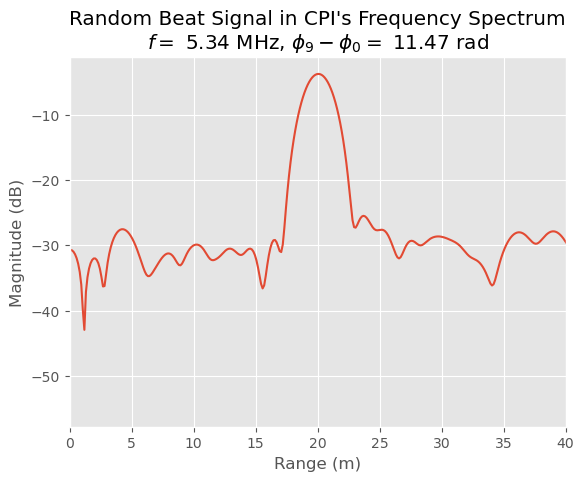

In [21]:
fft_len = N * 8  # FFT长度：将原始采样点数 N 扩展到 8 倍以提高频率分辨率
freq = np.linspace(-fs / 2, fs / 2, fft_len)  # 生成频率轴，范围从 -fs/2 到 fs/2

rmax = c * Tc * fs / (2 * bw)  # 最大可测距离 Rmax = c·Tc·fs/(2·bw)
n_ranges = np.linspace(-rmax / 2, rmax / 2, N)    
ranges   = np.linspace(-rmax / 2, rmax / 2, fft_len)  

# 对第 n 个 CPI 信号做 FFT，并将零频分量移动到中心
X_k = fftshift(fft(cpi_single[n], fft_len))
X_k /= N / 2          # 幅度归一化
X_k = np.abs(X_k)     # 计算幅度谱
X_k = 10 * np.log10(X_k)  # 转换为 dB 单位

fig, ax = plt.subplots()  
ax.set_title(
    f"Random Beat Signal in CPI's Frequency Spectrum\n"
    f"$f=\\ ${f_beat/1e6:.2f} MHz, $\\phi_{{{n}}}-\\phi_0=\\ ${n*phase_diff:.2f} rad"
)  # 标题：显示 beat 频率和相位差

# 在频率轴上绘制幅度谱（频率单位 MHz）
# ax.plot(freq / 1e6, X_k)
# ax.set_xlabel("Frequency (MHz)")  

# 如果需要在距离轴上绘制，将下面两行取消注释
ax.plot(ranges, X_k)
ax.set_xlabel("Range (m)")     

ax.set_ylabel("Magnitude (dB)")  
ax.set_xlim([0, 40])             
plt.show()                       

下面绘制速度维FFT以及绘制RDMap

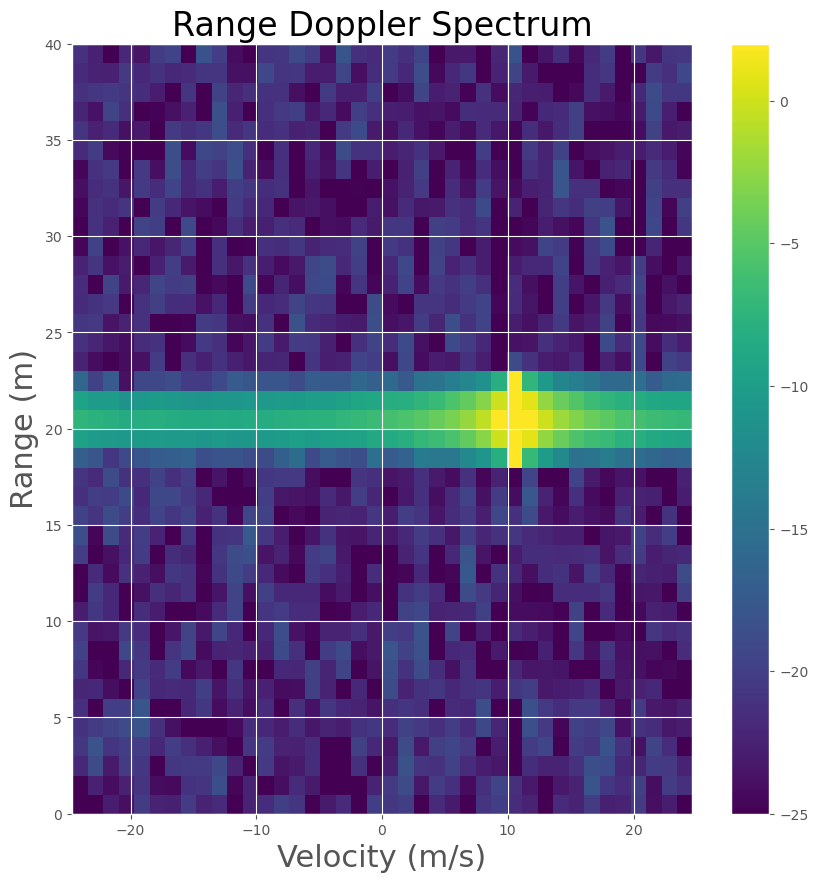

In [22]:
# 生成速度轴，范围从 -max_vel 到 max_vel，共 M 个点
vels = np.linspace(-max_vel, max_vel, M)

# 计算距离-多普勒二维谱：
# 对加窗并叠加噪声的 CPI 信号矩阵做二维 FFT
# cpi_single 的形状为 (M, N)，转置后每列为一个 Chirp
# fft2 返回 M×N 的频谱矩阵，fftshift 将零频移到中心
# 然后取幅值并归一化
range_doppler = fftshift(np.abs(fft2(cpi_single.T))) / (N / 2)

extent = [-max_vel, max_vel, ranges.min(), ranges.max()]

fig, ax = plt.subplots(figsize=(10, 10))  
range_doppler_plot = ax.imshow(
    10 * np.log10(range_doppler),  
    aspect="auto",                 
    extent=extent,                 
    origin="lower",                
    vmax=2,                        
    vmin=-25,                       
)

ax.set_ylim([0, 40])  
ax.set_title("Range Doppler Spectrum", fontsize=24) 
ax.set_xlabel("Velocity (m/s)", fontsize=22)         
ax.set_ylabel("Range (m)", fontsize=22)             
# ax.set_ylabel("Frequency (MHz)", fontsize=22)      

fig.colorbar(range_doppler_plot) 
plt.show() 

## 简单看下多目标情况

对于多个目标，信号方程变为

\begin{equation}
\sum_{m=1}^{M} \sum_{n=1}^{N} \sin\bigl(2 \pi f_{\mathrm{beat},n}\,t + m\,\Delta \phi_{n}\bigr)
\end{equation}

其中：

- $N$：扫描体积内的目标数量  
- $M$：CPI（Coherent Processing Interval，相干处理区间）中的 Chirp 数量  

简而言之，就是将多个目标回波信号相加在一起

Targets: 
	1: distance = 20.00 m, velocity = 10.00 m/s, relative power = 0.0 dB
	2: distance = 20.00 m, velocity = -8.00 m/s, relative power = -5.0 dB
	3: distance = 10.00 m, velocity = 5.00 m/s, relative power = -10.0 dB


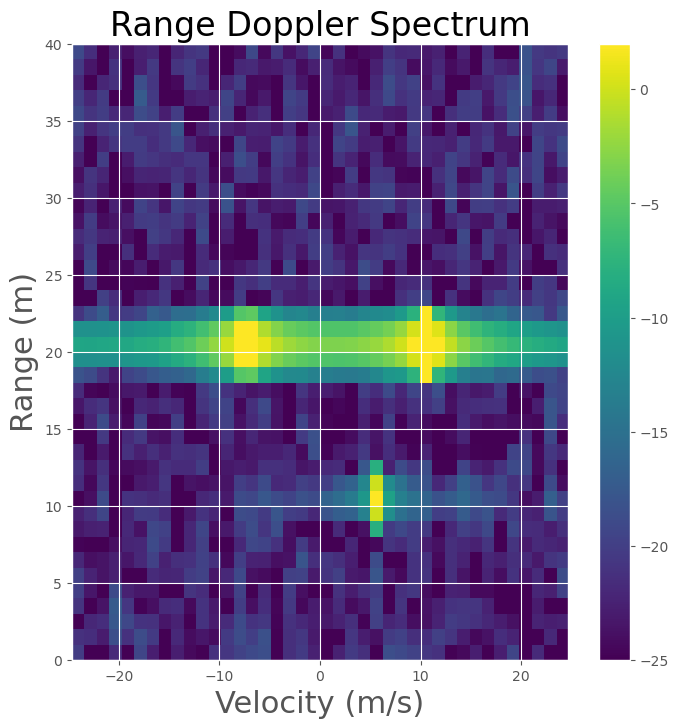

In [19]:
def db_to_lin(x):
    return 10 ** (x / 10)

# 设置多目标参数（距离、速度和能量）
targets = [
    (20, 10, 0),  # Target 1 @ 20 m with a velocity of 10 m/s and 0 dB relative power
    (20, -8, -5),  # Target 2 @ 20 m with a velocity of -8 m/s and -5 dB relative power
    (10, 5, -10),  # Target 3 @ 10 m with a velocity of 5 m/s and -10 dB relative power
]

sep = "\n\t"
print(
    f"Targets:",
    sep
    + sep.join(
        [
            f"{idx}: distance = {r:.2f} m, velocity = {v:.2f} m/s, relative power = {p:.1f} dB"
            for idx, (r, v, p) in enumerate(targets, start=1)
        ]
    ),
)

cpi = np.array(
    [
        (
            np.sum(
                [
                    np.sin(2 * pi * compute_f_beat(r) * t + m * compute_phase_diff(v))
                    * db_to_lin(p)
                    for r, v, p in targets
                ],
                axis=0,
            )
            + np.random.normal(0, 0.1, N)
        )
        * window
        for m in range(M)
    ]
)

range_doppler = fftshift(np.abs(fft2(cpi.T))) / (N / 2)

extent = [-max_vel, max_vel, ranges.min(), ranges.max()]

fig, ax = plt.subplots(figsize=(8, 8))
range_doppler_plot = ax.imshow(
    10 * np.log10(range_doppler),
    aspect="auto",
    extent=extent,
    origin="lower",
    vmax=2,
    vmin=-25,
)
ax.set_ylim([0, 40])
ax.set_title("Range Doppler Spectrum", fontsize=24)
ax.set_xlabel("Velocity (m/s)", fontsize=22)
ax.set_ylabel("Range (m)", fontsize=22)
# ax.set_ylabel("Frequency (MHz)", fontsize=22)
fig.colorbar(range_doppler_plot)
plt.show()